# Modulo 3 - Estacionariedad, heterocedasticidad y estacionalidad en Python

Curso: **Series Temporales con R y Python** (Frogames Formacion).

Codigo de acompanamiento de la leccion `03-caracteristicas-fundamentales/02-estacionariedad-heterocedasticidad-y-estacionalidad`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)

df_comp = pd.read_csv("indices_2015_2026.csv", parse_dates=["date"], index_col="date")
df_comp = df_comp.asfreq('B')
df_comp.spx = df_comp.spx.ffill()
df_comp.ftse = df_comp.ftse.bfill()
df_comp.dax = df_comp.dax.fillna(value=df_comp.dax.mean())
df_comp.nikkei = df_comp.nikkei.ffill().bfill()
df_comp['market_value'] = df_comp.spx
df_comp = df_comp[['market_value']]

size = int(len(df_comp) * 0.8)
df = df_comp.iloc[:size].copy()

wn = np.random.normal(loc=df.market_value.mean(), scale=df.market_value.std(), size=len(df))
df['wn'] = wn

steps = np.random.normal(loc=0, scale=1, size=len(df))
steps[0] = 0
df['rw'] = df.market_value.iloc[0] + np.cumsum(steps) * (df.market_value.std() * 0.01)
df.head()

,market_value,wn,rw
date,,,
2015-01-02,2058.199951,3663.742169,2058.199951
2015-01-05,2020.579956,3072.006838,2064.627326
2015-01-06,2002.609985,3804.434940,2059.940113
2015-01-07,2025.900024,4620.164011,2062.395546
2015-01-08,2062.139893,2982.647976,2065.137416


## Estacionariedad: el test de Dickey-Fuller aumentado (ADF)

Una serie es (debilmente) estacionaria si su media, varianza y autocovarianza no cambian con el tiempo. El test ADF contrasta H0: la serie NO es estacionaria (tiene raiz unitaria) frente a H1: la serie SI es estacionaria. Lo aplicamos a las tres series: la real, el ruido blanco y la caminata aleatoria.

In [2]:
adf_market = sts.adfuller(df.market_value)
print("market_value -- ADF stat:", round(adf_market[0], 4), " p-value:", adf_market[1])

adf_wn = sts.adfuller(df.wn)
print("wn           -- ADF stat:", round(adf_wn[0], 4), " p-value:", adf_wn[1])

adf_rw = sts.adfuller(df.rw)
print("rw           -- ADF stat:", round(adf_rw[0], 4), " p-value:", adf_rw[1])

market_value -- ADF stat: 0.0333  p-value: 0.9611997954599418
wn           -- ADF stat: -49.8687  p-value: 0.0
rw           -- ADF stat: -0.0088  p-value: 0.9577966011200023


/var/folders/1k/2gl0gzxd1t12r58tgchyn4dc0000gn/T/ipykernel_27299/772832968.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_market = sts.adfuller(df.market_value)
/var/folders/1k/2gl0gzxd1t12r58tgchyn4dc0000gn/T/ipykernel_27299/772832968.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_wn = sts.adfuller(df.wn)
/var/folders/1k/2gl0gzxd1t12r58tgchyn4dc0000gn/T

## Heterocedasticidad: la varianza no es constante

Heterocedasticidad significa que la varianza de la serie cambia con el tiempo -- justo lo que exige la estacionariedad que NO ocurra. La forma mas directa de verla es una desviacion tipica movil (rolling std) sobre los RETORNOS de la serie: si hay tramos con la banda mucho mas ancha que otros, hay heterocedasticidad.

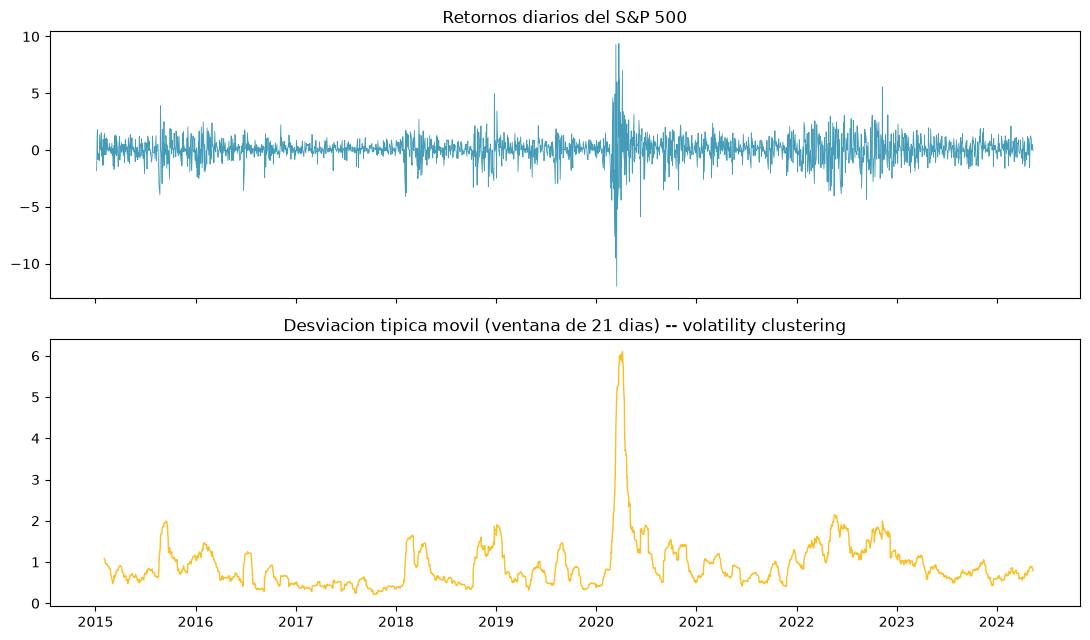

std en el tramo mas tranquilo (2017): 0.412
std en el tramo mas turbulento (marzo 2020): 4.251


In [3]:
returns = df.market_value.pct_change().dropna() * 100
rolling_std = returns.rolling(window=21).std()  # ventana de ~1 mes de trading

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
axes[0].plot(returns.index, returns, color='#449cb9', linewidth=0.6)
axes[0].set_title('Retornos diarios del S&P 500')
axes[1].plot(rolling_std.index, rolling_std, color='#fbbf24', linewidth=1)
axes[1].set_title('Desviacion tipica movil (ventana de 21 dias) -- volatility clustering')
plt.tight_layout()
plt.savefig('heterocedasticidad.png', dpi=130)
plt.show()

print("std en el tramo mas tranquilo (2017):", round(rolling_std['2017'].mean(), 3))
print("std en el tramo mas turbulento (marzo 2020):", round(rolling_std['2020-03'].mean(), 3))

## Estacionalidad: descomposicion aditiva y multiplicativa

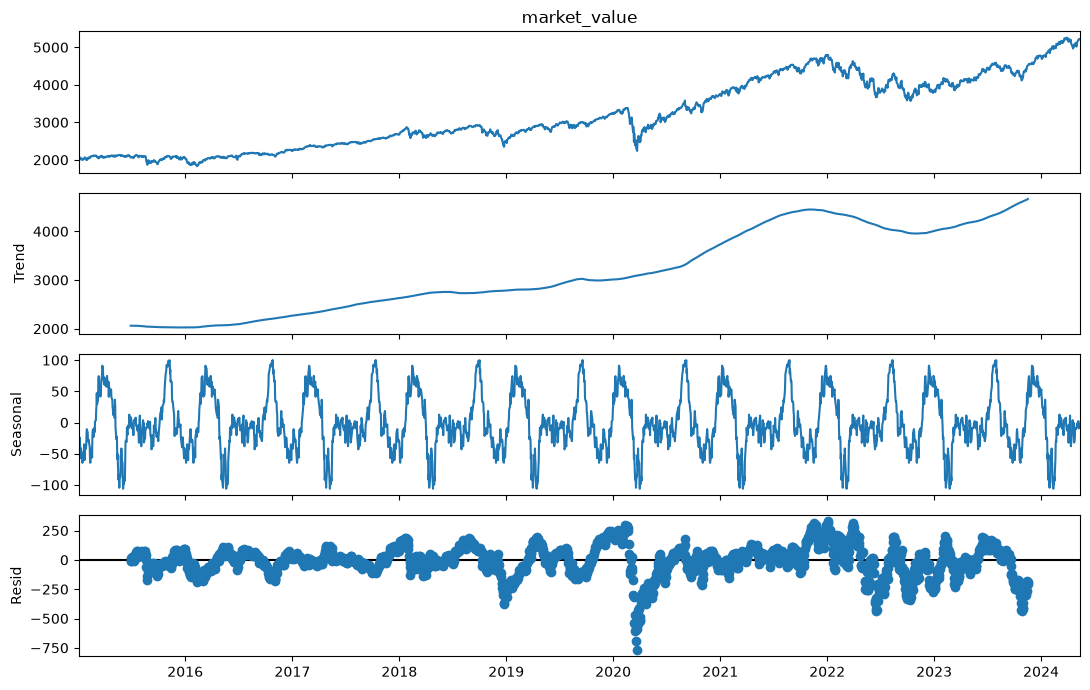

In [4]:
s_dec_additive = seasonal_decompose(df.market_value, model='additive', period=252)
fig = s_dec_additive.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.savefig('decompose_additive.png', dpi=130)
plt.show()

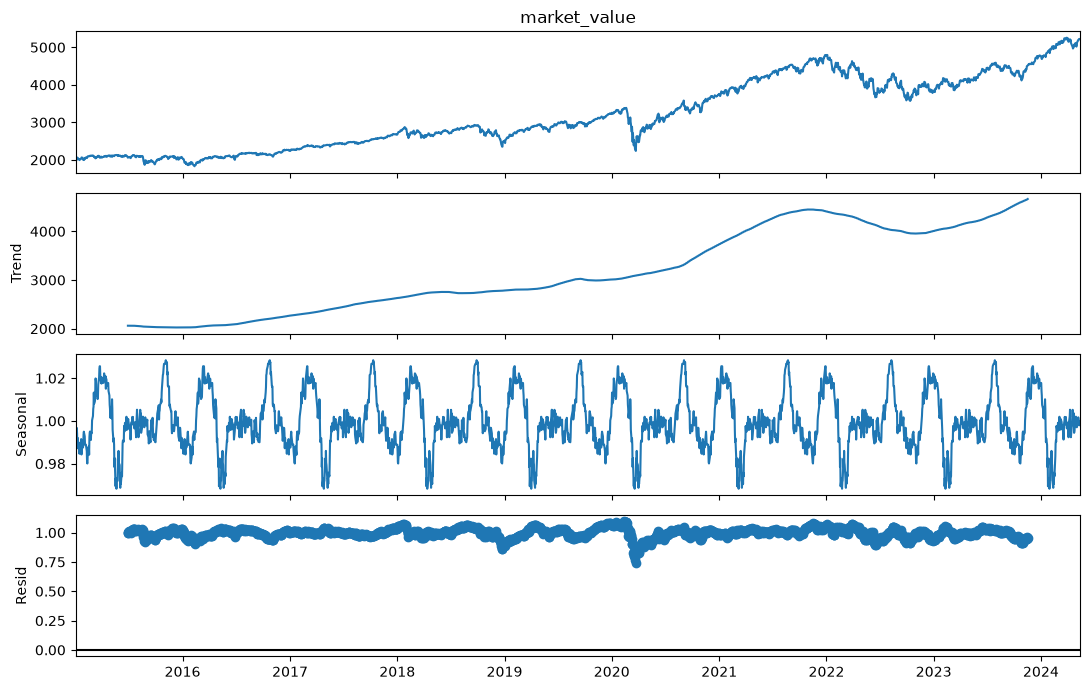

In [5]:
s_dec_mult = seasonal_decompose(df.market_value, model='multiplicative', period=252)
fig = s_dec_mult.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.savefig('decompose_multiplicative.png', dpi=130)
plt.show()

**Entregable**: reproduce estas celdas. Aplica el test ADF a los RETORNOS del S&P 500 (`df.market_value.pct_change().dropna()`) en vez de al precio -- compara el p-value contra el que obtuviste para `market_value` y explica por que cambia tan drasticamente.